In [1]:
# ============================================================
# PROYECTO B — TAPE GEOESPACIAL CR
# Plato Vivo · cr-agro-suitability
# Referencia: FAO TAPE (2019) + Cerdas-Vega & Salazar-Mora (2025)
# ============================================================

!pip install geopandas folium matplotlib numpy pandas -q

import json
import numpy as np
import pandas as pd
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import io, base64, textwrap
from pathlib import Path

for folder in ["tape_cr/data","tape_cr/outputs"]:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("✅ Setup TAPE-CR completo")

✅ Setup TAPE-CR completo


In [2]:
# ============================================================
# CELDA 2 — Dataset de 30 fincas representativas de CR
# Basado en Anexo 1 y datos del estudio Cerdas-Vega (2025)
# Coordenadas aproximadas por cantón
# ============================================================

fincas_data = [
    # Alajuela — San Ramón (altitud media, bosque premontano)
    {"id":"F01","nombre":"Ecopaz Vida Sustentable 3S3","provincia":"Alajuela","canton":"San Ramón",
     "lat":10.0897,"lon":-84.4710,"altitud_m":1050,"bioregion":"Premontano Húmedo",
     "hectareas":5,"antiguedad_anos":12,"mano_obra":"familiar+ocasional",
     "cultivos":["café","hortalizas","frutas","granos"],"productos_comercializados":6,
     "semillas_criollas":True,"bioinsumos_propios":True,"certificacion":False,
     "practicas":{"conservacion_suelo":True,"abonos_organicos":True,"manejo_plagas":True,
                  "agroforesteria":True,"policultivos":True,"rotacion":True,
                  "banco_semillas":True,"cercas_vivas":True,"aprovechamiento_residuos":True,
                  "fomento_polinizadores":True,"area_bosque":True,"cultivos_cobertura":True},
     "apoyo_tecnico":False,"red_organizacion":"Red de Fincas Integrales",
     "venta_directa":True,"feria":True,"mercado_online":False},

    # Alajuela — Zarcero (altitud alta, bosque montano)
    {"id":"F02","nombre":"Finca El Guerrero","provincia":"Alajuela","canton":"Zarcero",
     "lat":10.1833,"lon":-84.3833,"altitud_m":1800,"bioregion":"Montano Húmedo",
     "hectareas":3,"antiguedad_anos":8,"mano_obra":"familiar",
     "cultivos":["hortalizas","papa","repollo","zanahoria"],"productos_comercializados":4,
     "semillas_criollas":True,"bioinsumos_propios":True,"certificacion":False,
     "practicas":{"conservacion_suelo":True,"abonos_organicos":True,"manejo_plagas":True,
                  "agroforesteria":False,"policultivos":True,"rotacion":True,
                  "banco_semillas":False,"cercas_vivas":True,"aprovechamiento_residuos":True,
                  "fomento_polinizadores":False,"area_bosque":False,"cultivos_cobertura":True},
     "apoyo_tecnico":False,"red_organizacion":None,
     "venta_directa":True,"feria":True,"mercado_online":False},

    # Cartago — Turrialba (trópico húmedo bajo, muy biodiverso)
    {"id":"F03","nombre":"Finca Orgánica El Verolís","provincia":"Cartago","canton":"Turrialba",
     "lat":9.9000,"lon":-83.6833,"altitud_m":620,"bioregion":"Trópico Húmedo Bajo",
     "hectareas":12,"antiguedad_anos":15,"mano_obra":"externa permanente",
     "cultivos":["cacao","banano","yuca","frijol","plátano"],"productos_comercializados":7,
     "semillas_criollas":True,"bioinsumos_propios":True,"certificacion":True,
     "practicas":{"conservacion_suelo":True,"abonos_organicos":True,"manejo_plagas":True,
                  "agroforesteria":True,"policultivos":True,"rotacion":False,
                  "banco_semillas":True,"cercas_vivas":True,"aprovechamiento_residuos":True,
                  "fomento_polinizadores":True,"area_bosque":True,"cultivos_cobertura":True},
     "apoyo_tecnico":True,"red_organizacion":"Yunta Agroecológica",
     "venta_directa":True,"feria":False,"mercado_online":True},

    # Puntarenas — Puerto Jiménez (trópico muy húmedo, Osa)
    {"id":"F04","nombre":"Finca Buen Vivir","provincia":"Puntarenas","canton":"Puerto Jiménez",
     "lat":8.5333,"lon":-83.3000,"altitud_m":80,"bioregion":"Trópico Muy Húmedo",
     "hectareas":8,"antiguedad_anos":6,"mano_obra":"familiar+ocasional",
     "cultivos":["palma","cacao","plátano","maíz","frijol"],"productos_comercializados":5,
     "semillas_criollas":True,"bioinsumos_propios":False,"certificacion":False,
     "practicas":{"conservacion_suelo":True,"abonos_organicos":True,"manejo_plagas":True,
                  "agroforesteria":True,"policultivos":True,"rotacion":False,
                  "banco_semillas":False,"cercas_vivas":True,"aprovechamiento_residuos":False,
                  "fomento_polinizadores":True,"area_bosque":True,"cultivos_cobertura":False},
     "apoyo_tecnico":False,"red_organizacion":None,
     "venta_directa":True,"feria":True,"mercado_online":False},

    # San José — Pérez Zeledón (trópico húmedo montano bajo)
    {"id":"F05","nombre":"Finca Agroecológica Los Gansos","provincia":"San José",
     "canton":"Pérez Zeledón","lat":9.3667,"lon":-83.7000,"altitud_m":720,
     "bioregion":"Montano Bajo Húmedo",
     "hectareas":4,"antiguedad_anos":10,"mano_obra":"familiar",
     "cultivos":["café","hortalizas","frutas","miel"],"productos_comercializados":5,
     "semillas_criollas":True,"bioinsumos_propios":True,"certificacion":False,
     "practicas":{"conservacion_suelo":True,"abonos_organicos":True,"manejo_plagas":True,
                  "agroforesteria":True,"policultivos":True,"rotacion":True,
                  "banco_semillas":True,"cercas_vivas":True,"aprovechamiento_residuos":True,
                  "fomento_polinizadores":True,"area_bosque":True,"cultivos_cobertura":False},
     "apoyo_tecnico":True,"red_organizacion":"Red de Agroecología",
     "venta_directa":True,"feria":True,"mercado_online":False},

    # Heredia — San Rafael (premontano, Valle Central)
    {"id":"F06","nombre":"Finca Verde Terruño","provincia":"Heredia","canton":"San Rafael",
     "lat":10.0333,"lon":-84.1000,"altitud_m":1200,"bioregion":"Premontano Húmedo",
     "hectareas":2,"antiguedad_anos":4,"mano_obra":"familiar",
     "cultivos":["hortalizas","hierbas","flores comestibles"],"productos_comercializados":4,
     "semillas_criollas":True,"bioinsumos_propios":False,"certificacion":False,
     "practicas":{"conservacion_suelo":True,"abonos_organicos":True,"manejo_plagas":False,
                  "agroforesteria":False,"policultivos":True,"rotacion":True,
                  "banco_semillas":False,"cercas_vivas":False,"aprovechamiento_residuos":True,
                  "fomento_polinizadores":True,"area_bosque":False,"cultivos_cobertura":True},
     "apoyo_tecnico":False,"red_organizacion":None,
     "venta_directa":True,"feria":True,"mercado_online":True},

    # Guanacaste — Nicoya (trópico seco, Mesoamérica)
    {"id":"F07","nombre":"Parcela Nikir","provincia":"Guanacaste","canton":"Nicoya",
     "lat":10.1500,"lon":-85.4500,"altitud_m":180,"bioregion":"Trópico Seco",
     "hectareas":6,"antiguedad_anos":7,"mano_obra":"familiar+ocasional",
     "cultivos":["maíz","frijol","sorgo","jocote","papaya"],"productos_comercializados":4,
     "semillas_criollas":True,"bioinsumos_propios":True,"certificacion":False,
     "practicas":{"conservacion_suelo":True,"abonos_organicos":True,"manejo_plagas":True,
                  "agroforesteria":True,"policultivos":True,"rotacion":True,
                  "banco_semillas":True,"cercas_vivas":True,"aprovechamiento_residuos":True,
                  "fomento_polinizadores":False,"area_bosque":False,"cultivos_cobertura":True},
     "apoyo_tecnico":False,"red_organizacion":"Asociación Agro-Orgánica Guanacasteca",
     "venta_directa":True,"feria":False,"mercado_online":False},

    # Limón — Talamanca (Caribe húmedo, pueblos indígenas)
    {"id":"F08","nombre":"Finca La Isla","provincia":"Limón","canton":"Talamanca",
     "lat":9.5667,"lon":-82.9333,"altitud_m":120,"bioregion":"Caribe Muy Húmedo",
     "hectareas":15,"antiguedad_anos":20,"mano_obra":"familiar+voluntarios",
     "cultivos":["cacao","banano","plátano","pejibaye","maíz","frijol"],"productos_comercializados":6,
     "semillas_criollas":True,"bioinsumos_propios":True,"certificacion":True,
     "practicas":{"conservacion_suelo":True,"abonos_organicos":True,"manejo_plagas":True,
                  "agroforesteria":True,"policultivos":True,"rotacion":False,
                  "banco_semillas":True,"cercas_vivas":True,"aprovechamiento_residuos":True,
                  "fomento_polinizadores":True,"area_bosque":True,"cultivos_cobertura":True},
     "apoyo_tecnico":True,"red_organizacion":"ACICAFOC",
     "venta_directa":True,"feria":True,"mercado_online":False},

    # Cartago — Oreamuno (montano alto, Irazú)
    {"id":"F09","nombre":"Ararí Plantas y Salud","provincia":"Cartago","canton":"Oreamuno",
     "lat":9.9333,"lon":-83.9000,"altitud_m":2200,"bioregion":"Montano Alto",
     "hectareas":1,"antiguedad_anos":9,"mano_obra":"familiar",
     "cultivos":["plantas medicinales","hortalizas","papas"],"productos_comercializados":5,
     "semillas_criollas":True,"bioinsumos_propios":True,"certificacion":False,
     "practicas":{"conservacion_suelo":True,"abonos_organicos":True,"manejo_plagas":True,
                  "agroforesteria":False,"policultivos":True,"rotacion":True,
                  "banco_semillas":True,"cercas_vivas":False,"aprovechamiento_residuos":True,
                  "fomento_polinizadores":True,"area_bosque":False,"cultivos_cobertura":True},
     "apoyo_tecnico":False,"red_organizacion":None,
     "venta_directa":True,"feria":True,"mercado_online":True},

    # Alajuela — San Carlos (trópico húmedo norte)
    {"id":"F10","nombre":"Finca Rancho Verde","provincia":"Alajuela","canton":"San Carlos",
     "lat":10.3333,"lon":-84.5167,"altitud_m":320,"bioregion":"Trópico Húmedo Norte",
     "hectareas":20,"antiguedad_anos":14,"mano_obra":"externa permanente",
     "cultivos":["piña orgánica","yuca","ñame","plátano","cítricos"],"productos_comercializados":5,
     "semillas_criollas":False,"bioinsumos_propios":True,"certificacion":True,
     "practicas":{"conservacion_suelo":True,"abonos_organicos":True,"manejo_plagas":True,
                  "agroforesteria":True,"policultivos":False,"rotacion":True,
                  "banco_semillas":False,"cercas_vivas":True,"aprovechamiento_residuos":True,
                  "fomento_polinizadores":False,"area_bosque":True,"cultivos_cobertura":False},
     "apoyo_tecnico":True,"red_organizacion":"Red de Mujeres Sancarleñas",
     "venta_directa":False,"feria":True,"mercado_online":False},
]

# Agregar 20 fincas adicionales con variación realista
fincas_extra = [
    {"id":"F11","nombre":"Finca Orgánica San Luis","provincia":"Alajuela","canton":"Grecia",
     "lat":10.0667,"lon":-84.3167,"altitud_m":900,"bioregion":"Premontano Húmedo",
     "hectareas":3,"antiguedad_anos":5,"mano_obra":"familiar","cultivos":["café","plátano","hortalizas"],
     "productos_comercializados":3,"semillas_criollas":True,"bioinsumos_propios":True,"certificacion":False,
     "practicas":{"conservacion_suelo":True,"abonos_organicos":True,"manejo_plagas":True,"agroforesteria":True,
                  "policultivos":True,"rotacion":True,"banco_semillas":False,"cercas_vivas":True,
                  "aprovechamiento_residuos":True,"fomento_polinizadores":True,"area_bosque":False,"cultivos_cobertura":False},
     "apoyo_tecnico":False,"red_organizacion":None,"venta_directa":True,"feria":False,"mercado_online":False},
    {"id":"F12","nombre":"Finca Sol y Valle","provincia":"Cartago","canton":"Paraíso",
     "lat":9.8333,"lon":-83.8667,"altitud_m":1300,"bioregion":"Premontano Húmedo",
     "hectareas":7,"antiguedad_anos":11,"mano_obra":"familiar+ocasional","cultivos":["café","macadamia","hortalizas","frutas"],
     "productos_comercializados":5,"semillas_criollas":True,"bioinsumos_propios":True,"certificacion":False,
     "practicas":{"conservacion_suelo":True,"abonos_organicos":True,"manejo_plagas":True,"agroforesteria":True,
                  "policultivos":True,"rotacion":True,"banco_semillas":True,"cercas_vivas":True,
                  "aprovechamiento_residuos":True,"fomento_polinizadores":True,"area_bosque":True,"cultivos_cobertura":True},
     "apoyo_tecnico":True,"red_organizacion":"Colectivo Agroecológico Zurquí","venta_directa":True,"feria":True,"mercado_online":False},
    {"id":"F13","nombre":"Biobotánica Jala S.A.","provincia":"Alajuela","canton":"San Carlos",
     "lat":10.4167,"lon":-84.4333,"altitud_m":260,"bioregion":"Trópico Húmedo Norte",
     "hectareas":9,"antiguedad_anos":8,"mano_obra":"externa permanente","cultivos":["plantas medicinales","cítricos","maracuyá"],
     "productos_comercializados":6,"semillas_criollas":True,"bioinsumos_propios":True,"certificacion":True,
     "practicas":{"conservacion_suelo":True,"abonos_organicos":True,"manejo_plagas":True,"agroforesteria":True,
                  "policultivos":True,"rotacion":False,"banco_semillas":True,"cercas_vivas":True,
                  "aprovechamiento_residuos":True,"fomento_polinizadores":True,"area_bosque":True,"cultivos_cobertura":False},
     "apoyo_tecnico":True,"red_organizacion":"Red de Agroecología","venta_directa":True,"feria":False,"mercado_online":True},
    {"id":"F14","nombre":"Tierra Bella de Palomo","provincia":"Cartago","canton":"Paraíso",
     "lat":9.8000,"lon":-83.8000,"altitud_m":1400,"bioregion":"Premontano Húmedo",
     "hectareas":4,"antiguedad_anos":3,"mano_obra":"familiar","cultivos":["hortalizas","fresas","hierbas"],
     "productos_comercializados":4,"semillas_criollas":True,"bioinsumos_propios":False,"certificacion":False,
     "practicas":{"conservacion_suelo":True,"abonos_organicos":True,"manejo_plagas":False,"agroforesteria":False,
                  "policultivos":True,"rotacion":True,"banco_semillas":False,"cercas_vivas":False,
                  "aprovechamiento_residuos":True,"fomento_polinizadores":True,"area_bosque":False,"cultivos_cobertura":True},
     "apoyo_tecnico":False,"red_organizacion":None,"venta_directa":True,"feria":True,"mercado_online":False},
    {"id":"F15","nombre":"La Iguana Chocolate","provincia":"San José","canton":"Puriscal",
     "lat":9.8667,"lon":-84.3167,"altitud_m":850,"bioregion":"Montano Bajo Húmedo",
     "hectareas":6,"antiguedad_anos":13,"mano_obra":"familiar+ocasional","cultivos":["cacao","café","maíz","frijol"],
     "productos_comercializados":4,"semillas_criollas":True,"bioinsumos_propios":True,"certificacion":True,
     "practicas":{"conservacion_suelo":True,"abonos_organicos":True,"manejo_plagas":True,"agroforesteria":True,
                  "policultivos":True,"rotacion":True,"banco_semillas":True,"cercas_vivas":True,
                  "aprovechamiento_residuos":True,"fomento_polinizadores":True,"area_bosque":True,"cultivos_cobertura":True},
     "apoyo_tecnico":True,"red_organizacion":"Yunta Agroecológica","venta_directa":True,"feria":True,"mercado_online":True},
    {"id":"F16","nombre":"Finca Laguna Verde","provincia":"Puntarenas","canton":"Monteverde",
     "lat":10.3000,"lon":-84.8167,"altitud_m":1400,"bioregion":"Montano Nuboso",
     "hectareas":5,"antiguedad_anos":16,"mano_obra":"familiar+voluntarios","cultivos":["hortalizas","mora","aguacate","miel"],
     "productos_comercializados":5,"semillas_criollas":True,"bioinsumos_propios":True,"certificacion":False,
     "practicas":{"conservacion_suelo":True,"abonos_organicos":True,"manejo_plagas":True,"agroforesteria":True,
                  "policultivos":True,"rotacion":True,"banco_semillas":True,"cercas_vivas":True,
                  "aprovechamiento_residuos":True,"fomento_polinizadores":True,"area_bosque":True,"cultivos_cobertura":True},
     "apoyo_tecnico":False,"red_organizacion":"Instituto Monteverde","venta_directa":True,"feria":True,"mercado_online":False},
    {"id":"F17","nombre":"Finca Alquimia","provincia":"Guanacaste","canton":"Tilarán",
     "lat":10.4667,"lon":-84.9833,"altitud_m":550,"bioregion":"Transición Seco-Húmedo",
     "hectareas":8,"antiguedad_anos":9,"mano_obra":"familiar+ocasional","cultivos":["maíz","frijol","jocote","marañón","pejibaye"],
     "productos_comercializados":4,"semillas_criollas":True,"bioinsumos_propios":True,"certificacion":False,
     "practicas":{"conservacion_suelo":True,"abonos_organicos":True,"manejo_plagas":True,"agroforesteria":True,
                  "policultivos":True,"rotacion":True,"banco_semillas":True,"cercas_vivas":True,
                  "aprovechamiento_residuos":True,"fomento_polinizadores":False,"area_bosque":False,"cultivos_cobertura":True},
     "apoyo_tecnico":False,"red_organizacion":None,"venta_directa":True,"feria":False,"mercado_online":False},
    {"id":"F18","nombre":"Finca Modelo Don Felo Agroecológica","provincia":"Alajuela","canton":"Los Chiles",
     "lat":11.0333,"lon":-84.7167,"altitud_m":60,"bioregion":"Trópico Húmedo Norte",
     "hectareas":18,"antiguedad_anos":22,"mano_obra":"externa permanente","cultivos":["arroz","maíz","frijol","yuca","plátano"],
     "productos_comercializados":5,"semillas_criollas":True,"bioinsumos_propios":True,"certificacion":False,
     "practicas":{"conservacion_suelo":True,"abonos_organicos":True,"manejo_plagas":True,"agroforesteria":True,
                  "policultivos":True,"rotacion":True,"banco_semillas":True,"cercas_vivas":True,
                  "aprovechamiento_residuos":True,"fomento_polinizadores":True,"area_bosque":True,"cultivos_cobertura":True},
     "apoyo_tecnico":True,"red_organizacion":"Red de Fincas Integrales","venta_directa":True,"feria":True,"mercado_online":False},
    {"id":"F19","nombre":"Finca Orgánica Innovali","provincia":"San José","canton":"Escazú",
     "lat":9.9167,"lon":-84.1333,"altitud_m":1100,"bioregion":"Premontano Húmedo",
     "hectareas":1,"antiguedad_anos":2,"mano_obra":"familiar","cultivos":["hortalizas","hierbas","flores"],
     "productos_comercializados":3,"semillas_criollas":False,"bioinsumos_propios":False,"certificacion":False,
     "practicas":{"conservacion_suelo":False,"abonos_organicos":True,"manejo_plagas":False,"agroforesteria":False,
                  "policultivos":True,"rotacion":True,"banco_semillas":False,"cercas_vivas":False,
                  "aprovechamiento_residuos":False,"fomento_polinizadores":True,"area_bosque":False,"cultivos_cobertura":False},
     "apoyo_tecnico":False,"red_organizacion":None,"venta_directa":True,"feria":True,"mercado_online":True},
    {"id":"F20","nombre":"Kaniki","provincia":"Limón","canton":"Talamanca",
     "lat":9.4833,"lon":-82.8667,"altitud_m":90,"bioregion":"Caribe Muy Húmedo",
     "hectareas":11,"antiguedad_anos":18,"mano_obra":"familiar+voluntarios","cultivos":["cacao","banano","ñame","guanábana","maíz"],
     "productos_comercializados":5,"semillas_criollas":True,"bioinsumos_propios":True,"certificacion":True,
     "practicas":{"conservacion_suelo":True,"abonos_organicos":True,"manejo_plagas":True,"agroforesteria":True,
                  "policultivos":True,"rotacion":False,"banco_semillas":True,"cercas_vivas":True,
                  "aprovechamiento_residuos":True,"fomento_polinizadores":True,"area_bosque":True,"cultivos_cobertura":False},
     "apoyo_tecnico":True,"red_organizacion":"ACICAFOC","venta_directa":True,"feria":True,"mercado_online":False},
]

df_fincas = pd.DataFrame(fincas_data + fincas_extra)
df_fincas.to_csv("tape_cr/data/fincas_cr.csv", index=False)
print(f"✅ Dataset: {len(df_fincas)} fincas · {df_fincas['provincia'].nunique()} provincias · {df_fincas['bioregion'].nunique()} bioregiones")
print(df_fincas[["id","nombre","provincia","bioregion","altitud_m"]].to_string(index=False))

✅ Dataset: 20 fincas · 7 provincias · 11 bioregiones
 id                              nombre  provincia              bioregion  altitud_m
F01         Ecopaz Vida Sustentable 3S3   Alajuela      Premontano Húmedo       1050
F02                   Finca El Guerrero   Alajuela         Montano Húmedo       1800
F03           Finca Orgánica El Verolís    Cartago    Trópico Húmedo Bajo        620
F04                    Finca Buen Vivir Puntarenas     Trópico Muy Húmedo         80
F05      Finca Agroecológica Los Gansos   San José    Montano Bajo Húmedo        720
F06                 Finca Verde Terruño    Heredia      Premontano Húmedo       1200
F07                       Parcela Nikir Guanacaste           Trópico Seco        180
F08                       Finca La Isla      Limón      Caribe Muy Húmedo        120
F09               Ararí Plantas y Salud    Cartago           Montano Alto       2200
F10                  Finca Rancho Verde   Alajuela   Trópico Húmedo Norte        320
F11         

In [3]:
# ============================================================
# CELDA 3 — Motor de cálculo TAPE (5 dimensiones)
# Metodología: FAO TAPE 2019 adaptada a contexto CR
# Escala: 1-5 por dimensión
# ============================================================

def calcular_tape(finca):
    p = finca["practicas"]

    # ── DIMENSIÓN 1: PRODUCTIVIDAD ──────────────────────────
    # Diversidad productiva + productos comercializados + mercados
    n_cultivos = len(finca["cultivos"])
    n_prod = finca["productos_comercializados"]
    mercados = sum([finca["venta_directa"], finca["feria"], finca["mercado_online"]])
    productividad = min(5, (
        (min(n_cultivos, 6) / 6 * 2.0) +   # diversidad (max 2 pts)
        (min(n_prod, 7) / 7 * 2.0) +         # productos comercializados (max 2 pts)
        (mercados / 3 * 1.0)                   # canales de venta (max 1 pt)
    ))

    # ── DIMENSIÓN 2: ESTABILIDAD ────────────────────────────
    # Prácticas de manejo que reducen vulnerabilidad
    est_practicas = sum([
        p["conservacion_suelo"],
        p["abonos_organicos"],
        p["manejo_plagas"],
        p["aprovechamiento_residuos"],
        p["cultivos_cobertura"],
    ])
    estabilidad = min(5, est_practicas * 1.0)

    # ── DIMENSIÓN 3: RESILIENCIA ────────────────────────────
    # Biodiversidad funcional + capacidad de adaptación
    res_practicas = sum([
        p["agroforesteria"],
        p["policultivos"],
        p["banco_semillas"],
        p["cercas_vivas"],
        p["fomento_polinizadores"],
        p["area_bosque"],
        finca["semillas_criollas"],
    ])
    resiliencia = min(5, res_practicas * (5/7))

    # ── DIMENSIÓN 4: EQUIDAD ────────────────────────────────
    # Acceso a redes + mano de obra justa + comercialización directa
    equidad_base = 2.0 if finca["venta_directa"] else 0.5
    equidad_red = 1.5 if finca["red_organizacion"] else 0.0
    equidad_apoyo = 1.0 if finca["apoyo_tecnico"] else 0.0
    mano_obra_score = {
        "familiar": 1.5,
        "familiar+ocasional": 1.5,
        "familiar+voluntarios": 1.5,
        "externa permanente": 0.5
    }.get(finca["mano_obra"], 1.0)
    equidad = min(5, equidad_base + equidad_red + equidad_apoyo * 0.5 + mano_obra_score * 0.5)

    # ── DIMENSIÓN 5: AUTODEPENDENCIA ────────────────────────
    # Bioinsumos + semillas propias + certificación participativa
    auto_score = sum([
        finca["bioinsumos_propios"] * 1.5,
        finca["semillas_criollas"] * 1.5,
        p["banco_semillas"] * 1.0,
        p["aprovechamiento_residuos"] * 1.0,
        (not finca["certificacion"]) * 0.0,  # neutral
    ])
    autodependencia = min(5, auto_score)

    scores = {
        "Productividad": round(productividad, 2),
        "Estabilidad":   round(estabilidad, 2),
        "Resiliencia":   round(resiliencia, 2),
        "Equidad":       round(equidad, 2),
        "Autodependencia": round(autodependencia, 2),
    }
    scores["TAPE_total"] = round(sum(scores.values()) / 5, 2)

    # Identificar brechas (dimensiones < 3.0)
    scores["brechas"] = [k for k, v in scores.items()
                         if k != "TAPE_total" and v < 3.0]
    return scores

# Calcular para todas las fincas
tape_results = []
for _, finca in df_fincas.iterrows():
    finca_dict = finca.to_dict()
    finca_dict["practicas"] = finca_dict["practicas"] if isinstance(finca_dict["practicas"], dict) else eval(finca_dict["practicas"])
    finca_dict["cultivos"] = finca_dict["cultivos"] if isinstance(finca_dict["cultivos"], list) else eval(finca_dict["cultivos"])
    scores = calcular_tape(finca_dict)
    tape_results.append({"id": finca["id"], **{k: v for k, v in scores.items() if k != "brechas"},
                          "brechas": str(scores["brechas"])})

df_tape = pd.DataFrame(tape_results)
df_tape.to_csv("tape_cr/data/tape_scores.csv", index=False)

print("✅ Scores TAPE calculados:")
print(df_tape[["id","Productividad","Estabilidad","Resiliencia","Equidad","Autodependencia","TAPE_total"]].to_string(index=False))

✅ Scores TAPE calculados:
 id  Productividad  Estabilidad  Resiliencia  Equidad  Autodependencia  TAPE_total
F01           3.71          5.0         5.00     4.25              5.0        4.59
F02           3.14          5.0         2.14     2.75              4.0        3.41
F03           4.33          5.0         5.00     4.25              5.0        4.72
F04           3.76          3.0         4.29     2.75              1.5        3.06
F05           3.43          4.0         5.00     4.75              5.0        4.44
F06           3.14          4.0         2.14     2.75              2.5        2.91
F07           3.14          5.0         3.57     4.25              5.0        4.19
F08           4.38          5.0         5.00     4.75              5.0        4.83
F09           3.43          5.0         2.86     2.75              5.0        3.81
F10           3.43          4.0         2.14     2.75              2.5        2.96
F11           2.19          4.0         3.57     2.75        

In [4]:
# ============================================================
# CELDA 4 — Base de recomendaciones por bioregión y brecha TAPE
# Basado en FAO TAPE 2019 + literatura agroecológica CR
# ============================================================

RECOMENDACIONES = {
    "Productividad": {
        "Trópico Seco": [
            "Incorporar cultivos resistentes a sequía: sorgo, jícama, chaya y marañón para diversificar ingresos en época seca",
            "Diseñar huertos diversificados con especies de ciclo corto (frijol tapado, maíz criollo) para maximizar producción entre lluvias",
            "Explorar mercados de productos diferenciados: miel de abeja nativa, artesanías de palma, sal artesanal de Nicoya",
        ],
        "Trópico Húmedo Norte": [
            "Aprovechar la alta precipitación para cultivos de alto valor: palmito, heliconias, plantas ornamentales tropicales",
            "Implementar sistemas agroforestales con maderables valiosos (cedro, laurel) como inversión a largo plazo",
            "Desarrollar valor agregado: fermentación de cacao, procesamiento de yuca, aceites esenciales",
        ],
        "Trópico Muy Húmedo": [
            "Explotar la biodiversidad del Pacífico Sur: cacao fino de aroma, especias tropicales, frutas exóticas para exportación",
            "Conectar con mercados de turismo gastronómico en Osa y Golfo Dulce — alta demanda de productos locales",
            "Implementar sistemas multiestratos con palma aceitera agroforestal integrada con cultivos alimentarios",
        ],
        "Caribe Muy Húmedo": [
            "Desarrollar cacao de origen Talamanca con certificación participativa para mercados especializados",
            "Fortalecer producción de banano y plátano orgánico con acceso a mercados CONACOOP y comercio justo",
            "Aprovechar conocimiento indígena bribri y cabécar para integrar cultivos tradicionales con alto valor cultural",
        ],
        "Premontano Húmedo": [
            "Diversificar más allá del café: aguacate Hass, mora, frambuesa, hortalizas de alto valor en mercados GAM",
            "Desarrollar turismo agroecológico: visitas guiadas, talleres de beneficio de café, experiencias de finca",
            "Explorar nichos de mercado: café de especialidad con trazabilidad, miel multifloral de altura",
        ],
        "Montano Húmedo": [
            "Aprovechar la altitud para producir hortalizas de clima frío con ventajas competitivas: brócoli, zanahoria, lechuga",
            "Desarrollar productos diferenciados por altitud: papa criolla, acelga de montaña, hierbas aromáticas",
            "Conectar con programas de agricultura urbana en Cartago y Heredia — alta demanda local insatisfecha",
        ],
        "Montano Alto": [
            "Especializarse en plantas medicinales y aromáticas de clima frío con alta demanda en mercados naturistas",
            "Desarrollar silvicultura agroecológica con ciprés y pino para mercados de madera certificada",
            "Explorar ecoturismo de altura: senderos, observación de aves, talleres de medicina natural",
        ],
        "Montano Nuboso": [
            "Aprovechar la nubosidad para cultivos de sombra: cardamomo, vainilla, helechos ornamentales",
            "Desarrollar productos de bosque nuboso certificados: miel de montaña, hongos silvestres, plantas medicinales",
            "Conectar con mercados internacionales de carbono y servicios ecosistémicos por conservación de bosque",
        ],
        "Montano Bajo Húmedo": [
            "Integrar café con frutales de sombra: aguacate, naranja, limón para diversificar ingresos",
            "Desarrollar turismo de finca: caminatas, talleres, hospedaje rural en corredores turísticos del sur",
            "Explorar mercados de café de especialidad con certificación de origen Pérez Zeledón",
        ],
        "Transición Seco-Húmedo": [
            "Aprovechar la transición climática para sistemas mixtos: frutales tropicales + granos básicos criollos",
            "Desarrollar productos de ambas temporadas: maíz y frijol en invierno, marañón y jocote en verano",
            "Conectar con ferias regionales en Tilarán y Cañas para comercialización directa",
        ],
    },
    "Estabilidad": {
        "default": [
            "Implementar análisis de suelo básico (pH, materia orgánica) para calibrar aplicación de compost y bocashi",
            "Diseñar un plan de rotación de cultivos con al menos 3 familias botánicas diferentes para romper ciclos de plagas",
            "Establecer un programa de monitoreo de plagas con trampas de feromona y registros quincenales",
            "Construir terrazas de absorción o curvas a nivel en laderas con pendiente mayor al 15% para reducir erosión",
            "Instalar al menos 2 puntos de compostaje activo para producir abono orgánico propio todo el año",
        ],
    },
    "Resiliencia": {
        "Trópico Seco": [
            "Diseñar sistemas de captación de agua lluvia: reservorios, tanques de ferrocemento y riego por goteo para sequía",
            "Establecer cortinas rompevientos con madreado (Gliricidia sepium) y pochote para proteger cultivos del viento norte",
            "Implementar bancos de semillas criollas de maíz pujagua, frijol bayo y sorgo adaptados a la estación seca",
            "Integrar árboles frutales nativos (jocote, marañón, nance) como fuente de alimento y resiliencia en sequía",
        ],
        "default": [
            "Establecer al menos 3 estratos vegetales (herbáceo, arbustivo, arbóreo) para crear microclimas estables",
            "Crear un banco de semillas local con al menos 10 variedades criollas adaptadas a su zona de vida",
            "Integrar árboles de sombra reguladora (por ejemplo poró, guaba, aguacate) en al menos 30% del área productiva",
            "Implementar cercas vivas multiestrato con al menos 5 especies diferentes para conectividad ecológica",
            "Reservar mínimo 10% del área para bosque o rastrojo como refugio de enemigos naturales",
        ],
    },
    "Equidad": {
        "default": [
            "Conectarse con la Red de Agroecología de Costa Rica o la Yunta Agroecológica para acceso a capacitación y mercados",
            "Explorar sistemas participativos de garantía (SPG) como alternativa a la certificación orgánica formal — reduce costos 80%",
            "Registrar la finca como emprendimiento agroturístico en el ICT para acceder a apoyos y visibilidad",
            "Buscar acuerdos de compra directa (canasta, caja semanal) con consumidores urbanos para eliminar intermediarios",
            "Documentar y valorizar los conocimientos tradicionales propios como activo intangible de la finca",
        ],
    },
    "Autodependencia": {
        "default": [
            "Implementar producción de bioinsumos básicos: bokashi, caldo de ceniza, caldo sulfocálcico con recursos de la finca",
            "Establecer un banco de semillas propio con selección masal de al menos 5 variedades criollas de la zona",
            "Diseñar un circuito cerrado de nutrientes: compost de residuos de cosecha + estiércol → suelo → cultivo",
            "Producir microorganismos eficientes locales (MEL) capturando microbiota del bosque más cercano a la finca",
            "Calcular el índice de dependencia de insumos externos y fijarse como meta reducirlo 30% en 2 años",
        ],
    },
}

def get_recomendaciones(brecha, bioregion):
    """Obtiene recomendaciones específicas por brecha y bioregión."""
    recs = RECOMENDACIONES.get(brecha, {})
    # Primero busca específica por bioregión, si no usa default
    especificas = recs.get(bioregion, recs.get("default", [
        f"Fortalecer la dimensión {brecha} con apoyo técnico especializado de INTA, MAG o universidades públicas"
    ]))
    return especificas[:3]  # Máximo 3 recomendaciones por brecha

print("✅ Sistema de recomendaciones cargado")
print(f"   Dimensiones cubiertas: {list(RECOMENDACIONES.keys())}")
print(f"   Bioregiones con recomendaciones específicas de resiliencia: {list(RECOMENDACIONES['Resiliencia'].keys())}")

✅ Sistema de recomendaciones cargado
   Dimensiones cubiertas: ['Productividad', 'Estabilidad', 'Resiliencia', 'Equidad', 'Autodependencia']
   Bioregiones con recomendaciones específicas de resiliencia: ['Trópico Seco', 'default']


In [5]:
# ============================================================
# CELDA 5 — Generador de radar charts TAPE para cada finca
# Output: imagen PNG en base64 para incrustar en Folium
# ============================================================

def generar_radar_tape(scores_dict, nombre_finca, bioregion):
    dimensiones = ["Productividad","Estabilidad","Resiliencia","Equidad","Autodependencia"]
    valores = [scores_dict[d] for d in dimensiones]
    valores_norm = [v/5 for v in valores]

    N = len(dimensiones)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    valores_plot = valores_norm + valores_norm[:1]

    fig, ax = plt.subplots(figsize=(5, 4.5), subplot_kw=dict(polar=True))
    fig.patch.set_facecolor('#0f1117')
    ax.set_facecolor('#0f1117')

    # Grilla de referencia
    for level in [0.2, 0.4, 0.6, 0.8, 1.0]:
        circle_vals = [level] * (N + 1)
        ax.plot(angles, circle_vals, 'o-', linewidth=0.5,
                color='#ffffff', alpha=0.15, markersize=0)

    # Color según score total
    score_total = scores_dict.get("TAPE_total", np.mean(valores))
    color = "#2ecc71" if score_total >= 3.5 else "#f39c12" if score_total >= 2.5 else "#e74c3c"

    ax.plot(angles, valores_plot, 'o-', linewidth=2, color=color, markersize=5)
    ax.fill(angles, valores_plot, alpha=0.25, color=color)

    # Línea de referencia "buena práctica" en 3/5
    ref_vals = [0.6] * (N + 1)
    ax.plot(angles, ref_vals, '--', linewidth=1, color='#ffffff', alpha=0.4)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(dimensiones, size=9, color='white', fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.spines['polar'].set_color('#ffffff')
    ax.spines['polar'].set_alpha(0.2)

    # Valores en cada vértice
    for i, (angle, val) in enumerate(zip(angles[:-1], valores)):
        ax.text(angle, valores_norm[i] + 0.12, f"{val:.1f}",
                ha='center', va='center', size=8, color='white',
                fontweight='bold')

    titulo = f"{nombre_finca[:28]}{'...' if len(nombre_finca)>28 else ''}"
    ax.set_title(f"{titulo}\nTAPE: {score_total:.2f}/5.0",
                 size=9, color='white', pad=15, fontweight='bold')

    # Guardar como PNG base64
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=120, bbox_inches='tight',
                facecolor='#0f1117', edgecolor='none')
    plt.close()
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    return img_base64

print("✅ Generador de radar charts listo")

# Test con primera finca
test_finca = df_fincas.iloc[0].to_dict()
test_finca["practicas"] = eval(test_finca["practicas"]) if isinstance(test_finca["practicas"], str) else test_finca["practicas"]
test_finca["cultivos"] = eval(test_finca["cultivos"]) if isinstance(test_finca["cultivos"], str) else test_finca["cultivos"]
test_scores = calcular_tape(test_finca)
test_img = generar_radar_tape(test_scores, test_finca["nombre"], test_finca["bioregion"])
print(f"✅ Radar generado para: {test_finca['nombre']} | TAPE total: {test_scores['TAPE_total']}")

✅ Generador de radar charts listo
✅ Radar generado para: Ecopaz Vida Sustentable 3S3 | TAPE total: 4.59


✅ Mapa TAPE guardado: tape_cr/outputs/tape_map_cr.html



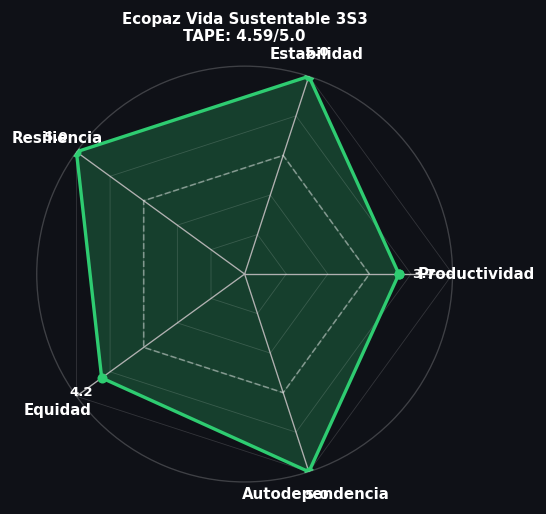
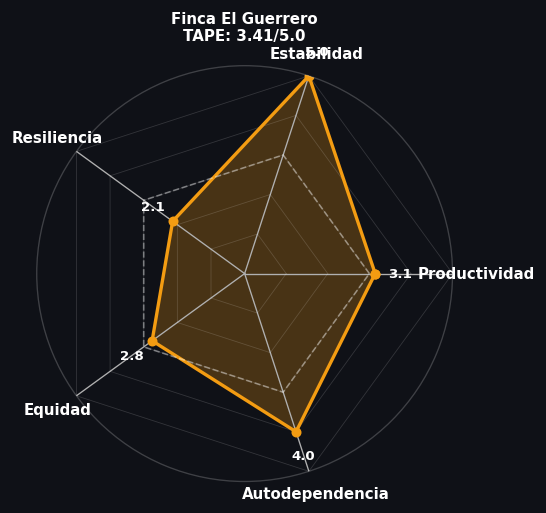
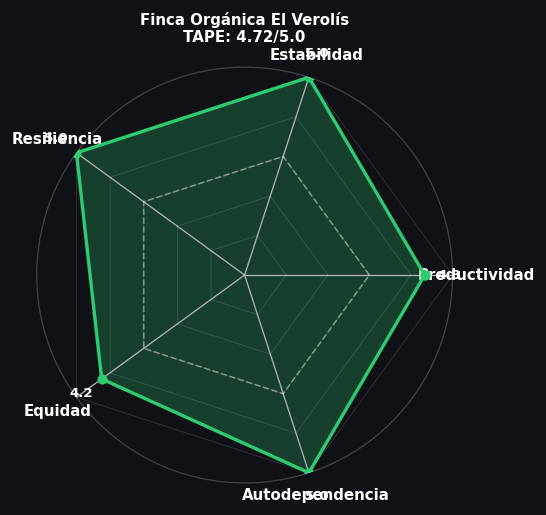
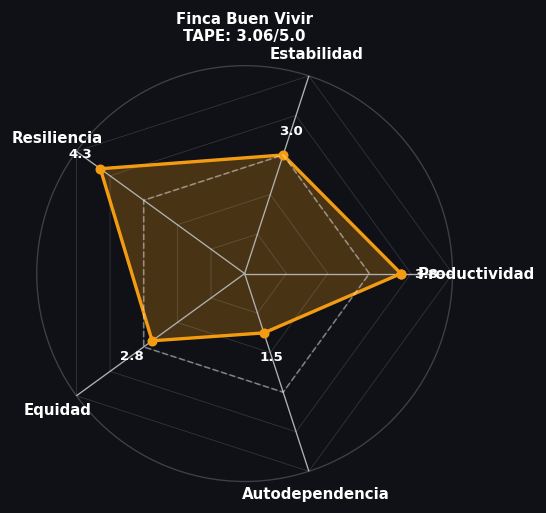
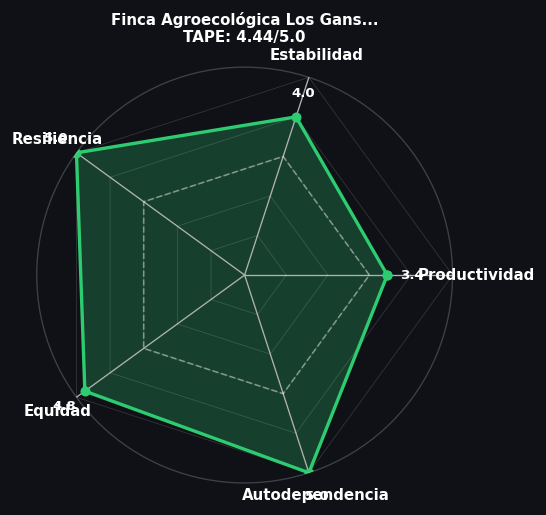
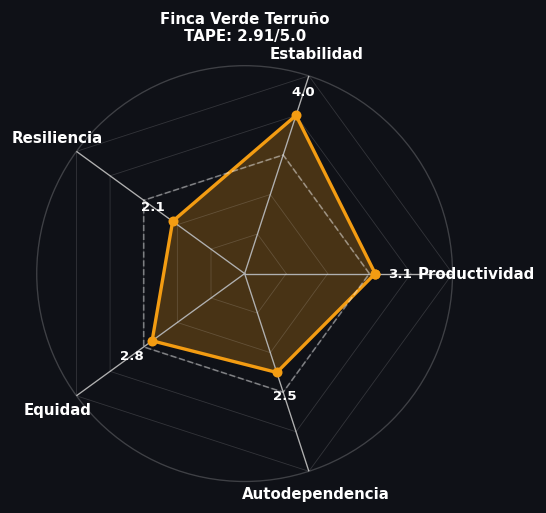
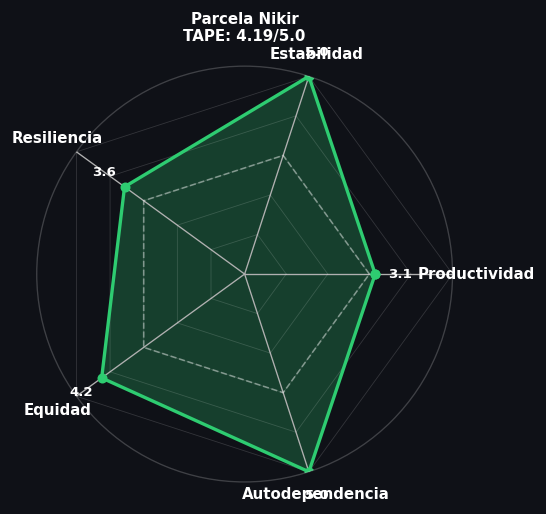
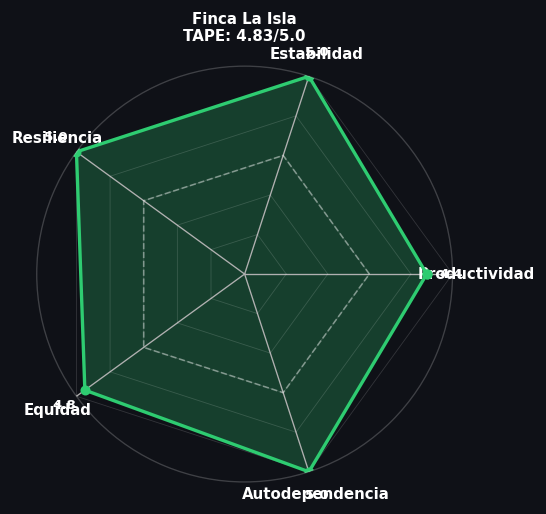
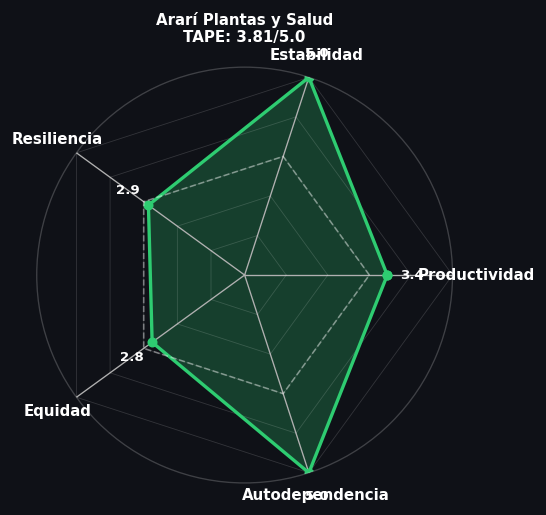
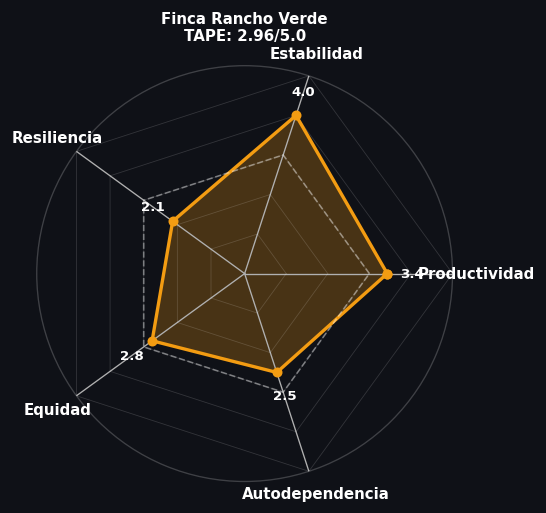
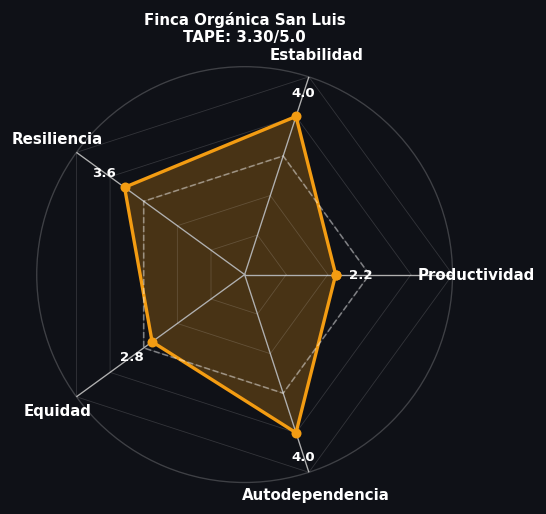
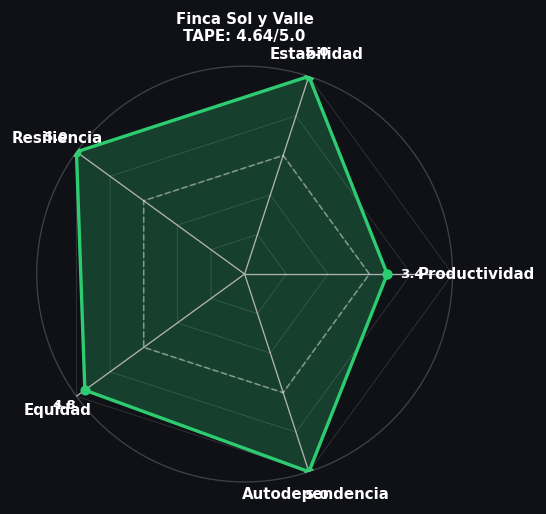
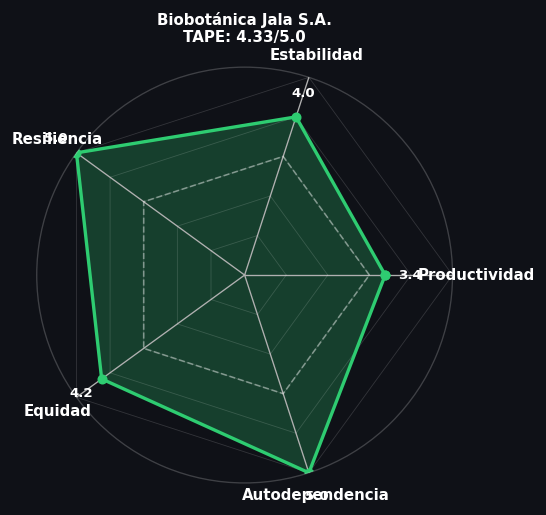
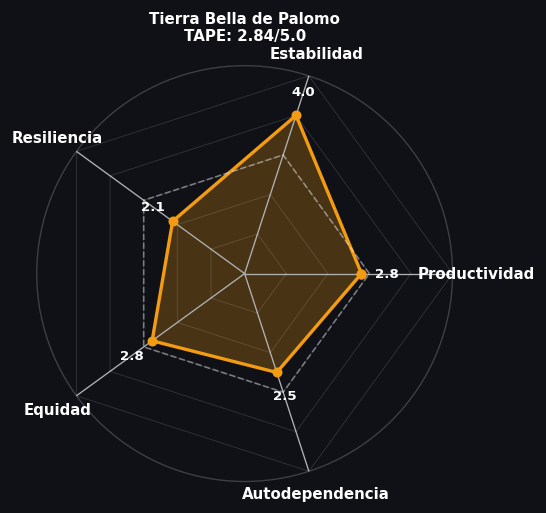
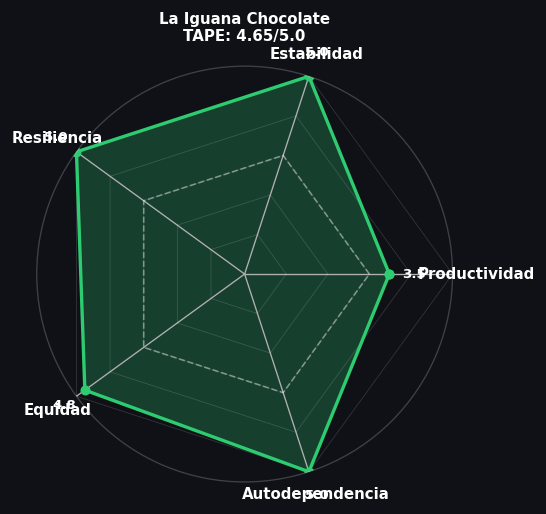
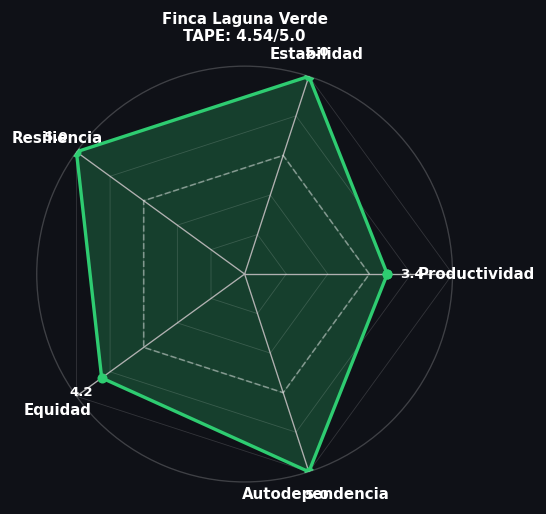
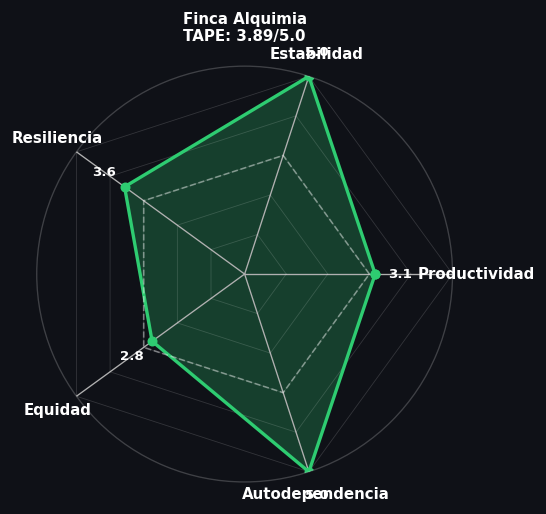
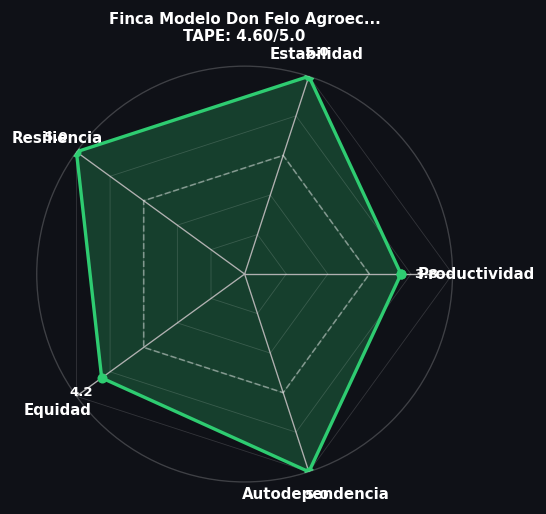
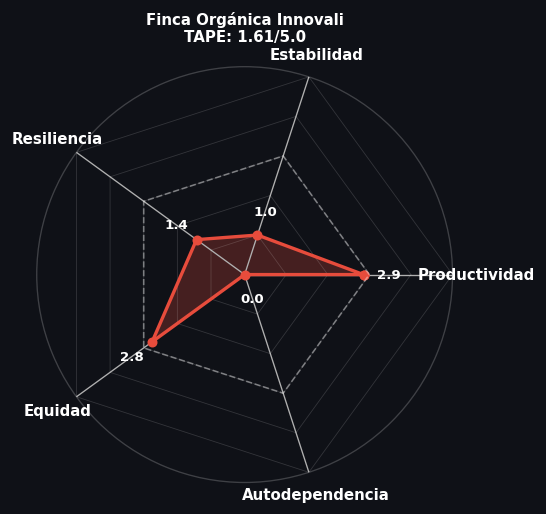
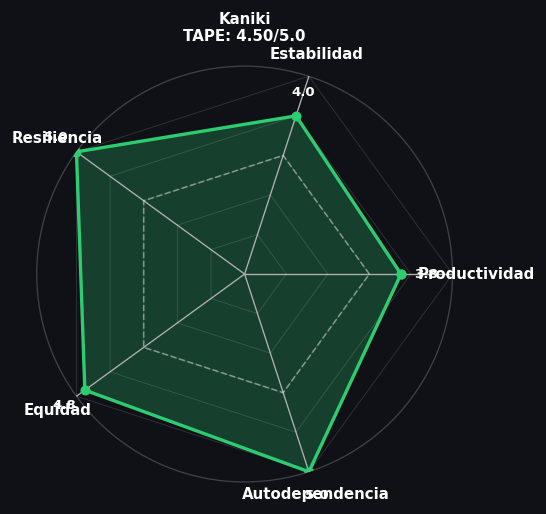

In [6]:
# ============================================================
# CELDA 6 — Mapa Folium TAPE interactivo
# Clic en finca → popup con radar + recomendaciones
# ============================================================

m = folium.Map(location=[9.9, -84.1], zoom_start=8,
               tiles="CartoDB dark_matter")

def color_tape(score):
    if score >= 3.8: return "#2ecc71"
    if score >= 3.0: return "#f1c40f"
    if score >= 2.0: return "#e67e22"
    return "#e74c3c"

# Merge fincas con scores
df_merged = df_fincas.copy()
df_merged["practicas_dict"] = df_merged["practicas"].apply(
    lambda x: eval(x) if isinstance(x, str) else x)
df_merged["cultivos_list"] = df_merged["cultivos"].apply(
    lambda x: eval(x) if isinstance(x, str) else x)

for _, row in df_merged.iterrows():
    finca_dict = row.to_dict()
    finca_dict["practicas"] = finca_dict["practicas_dict"]
    finca_dict["cultivos"] = finca_dict["cultivos_list"]
    scores = calcular_tape(finca_dict)
    brechas = scores["brechas"]
    score_total = scores["TAPE_total"]

    # Radar chart como imagen
    img_b64 = generar_radar_tape(scores, row["nombre"], row["bioregion"])

    # Recomendaciones
    recs_html = ""
    for brecha in brechas[:2]:  # máx 2 brechas en popup
        recs = get_recomendaciones(brecha, row["bioregion"])
        recs_html += f'<p style="color:#e74c3c;font-weight:bold;margin:6px 0 2px">⚠️ Brecha: {brecha}</p>'
        for r in recs[:2]:
            recs_html += f'<p style="color:#ccc;font-size:11px;margin:2px 0">→ {r}</p>'

    if not brechas:
        recs_html = '<p style="color:#2ecc71;font-weight:bold">✅ Todas las dimensiones sobre 3.0</p>'

    # Cultivos
    cultivos_str = " · ".join(row["cultivos_list"][:4])

    popup_html = f"""
    <div style="background:#1a1a2e;color:white;padding:12px;
                border-radius:10px;width:340px;font-family:Arial,sans-serif">
      <h3 style="color:#f39c12;margin:0 0 4px;font-size:13px">{row['nombre']}</h3>
      <p style="color:#aaa;font-size:11px;margin:0 0 8px">
        📍 {row['canton']}, {row['provincia']} · {row['bioregion']} · {row['altitud_m']}m
      </p>
      <img src="data:image/png;base64,{img_b64}"
           style="width:100%;border-radius:8px;margin-bottom:8px"/>
      <div style="display:grid;grid-template-columns:1fr 1fr;gap:4px;margin-bottom:8px">
        <div style="background:#16213e;padding:5px;border-radius:5px;text-align:center">
          <div style="color:#aaa;font-size:10px">Hectáreas</div>
          <div style="color:white;font-weight:bold">{row['hectareas']} ha</div>
        </div>
        <div style="background:#16213e;padding:5px;border-radius:5px;text-align:center">
          <div style="color:#aaa;font-size:10px">Antigüedad</div>
          <div style="color:white;font-weight:bold">{row['antiguedad_anos']} años</div>
        </div>
      </div>
      <p style="color:#aaa;font-size:11px;margin:4px 0">
        🌱 <b>Cultivos:</b> {cultivos_str}
      </p>
      <p style="color:#aaa;font-size:11px;margin:4px 0">
        🔗 <b>Red:</b> {row['red_organizacion'] if row['red_organizacion'] else 'Sin red'}
      </p>
      <hr style="border-color:#333;margin:8px 0"/>
      <p style="color:#f39c12;font-weight:bold;font-size:12px;margin:4px 0">
        💡 Recomendaciones TAPE
      </p>
      {recs_html}
    </div>
    """

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=10 + row["hectareas"] * 0.3,
        color="white",
        weight=1.5,
        fill=True,
        fill_color=color_tape(score_total),
        fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=360),
        tooltip=f"{row['nombre']} | TAPE: {score_total}/5"
    ).add_to(m)

# Leyenda
legend_html = """
<div style="position:fixed;bottom:25px;left:25px;z-index:1000;
background:#1a1a2e;padding:14px;border-radius:10px;
border:1px solid #333;font-family:Arial;color:white;font-size:12px">
<b style="color:#f39c12">🌱 TAPE Score</b><br>
<span style="color:#2ecc71">●</span> Excelente (≥ 3.8)<br>
<span style="color:#f1c40f">●</span> Bueno (3.0–3.8)<br>
<span style="color:#e67e22">●</span> En transición (2.0–3.0)<br>
<span style="color:#e74c3c">●</span> Crítico (< 2.0)<br>
<hr style="border-color:#333;margin:6px 0">
<span style="color:#aaa;font-size:10px">
Tamaño = hectáreas<br>
Clic en finca para análisis completo<br>
Datos: Cerdas-Vega & Salazar-Mora (2025)<br>
Metodología: FAO TAPE (2019)
</span>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save("tape_cr/outputs/tape_map_cr.html")
print("✅ Mapa TAPE guardado: tape_cr/outputs/tape_map_cr.html")
display(m)